In [1]:
import pandas as pd

# Load  dataset
df = pd.read_csv('iperbole-wifi-affollamento.csv',sep=';')


In [2]:
df.drop(inplace=True,columns='id.1')

In [3]:
float(df['geo_point_2d'][0].split(', ')[0])

df['lat']=[float(e.split(', ')[0]) for e in df['geo_point_2d']]
df['long']=[float(e.split(', ')[1]) for e in df['geo_point_2d']]

In [4]:
df.drop(inplace=True,columns='geo_point_2d')

In [5]:
df.drop(inplace=True,columns='shape_copertura')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264494 entries, 0 to 264493
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   codice_zona         264494 non-null  str    
 1   nome_zona           264494 non-null  str    
 2   data                264494 non-null  str    
 3   giorno              264494 non-null  str    
 4   ora                 264494 non-null  int64  
 5   affollamento_medio  264494 non-null  int64  
 6   lat                 264494 non-null  float64
 7   long                264494 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 16.1 MB


In [7]:
df.head()

,codice_zona,nome_zona,data,giorno,ora,affollamento_medio,lat,long
0,comune_liber_paradisus,Comune / Piazza Liber Paradisus,2026-01-05T08:00:00+00:00,1-Lunedi,9,110,44.509630,11.340079
1,giardino_vittime_macinella,Giardino Vittime di Marcinelle e Caduti,2026-01-05T08:00:00+00:00,1-Lunedi,9,50,44.505008,11.367729
2,laboratorio_interculturale,Biblioteca del Laboratorio Interculturale,2026-01-05T08:00:00+00:00,1-Lunedi,9,10,44.492325,11.334051
3,mambo,Mambo,2026-01-05T08:00:00+00:00,1-Lunedi,9,30,44.502577,11.336834
4,mercato_san_donato,Mercato San Donato,2026-01-05T08:00:00+00:00,1-Lunedi,9,0,44.502019,11.362215


In [8]:
df.describe()

,ora,affollamento_medio,lat,long
count,264494.000000,264494.000000,264494.000000,264494.000000
mean,11.499323,40.530409,44.499749,11.345115
std,6.922649,91.693851,0.012087,0.025767
min,0.000000,0.000000,44.473549,11.265671
25%,5.000000,0.000000,44.492867,11.335924
50%,11.000000,10.000000,44.496882,11.344318
75%,17.000000,30.000000,44.504597,11.357190
max,23.000000,1770.000000,44.546273,11.394655


In [9]:
df.corr(numeric_only=True)

,ora,affollamento_medio,lat,long
ora,1.000000,0.138791,0.000050,0.000007
affollamento_medio,0.138791,1.000000,-0.062916,-0.019156
lat,0.000050,-0.062916,1.000000,-0.193572
long,0.000007,-0.019156,-0.193572,1.000000


In [10]:

df['data']=[d.split('T')[0] for d in df['data']]

date_convertite = pd.to_datetime(df['data']).dt.date

print(date_convertite.nunique())

146


In [11]:
date_convertite

0         2026-01-05
1         2026-01-05
2         2026-01-05
3         2026-01-05
4         2026-01-05
             ...    
264489    2026-01-14
264490    2026-01-14
264491    2026-01-14
264492    2026-01-14
264493    2026-01-14
Name: data, Length: 264494, dtype: object

In [12]:
map_data_int={}
lista_date=date_convertite.unique().tolist()
lista_date.sort()
print(lista_date)
map_data_int={str(data): i for i,data in enumerate(lista_date)}
print(map_data_int)

[datetime.date(2025, 12, 31), datetime.date(2026, 1, 1), datetime.date(2026, 1, 2), datetime.date(2026, 1, 3), datetime.date(2026, 1, 4), datetime.date(2026, 1, 5), datetime.date(2026, 1, 6), datetime.date(2026, 1, 7), datetime.date(2026, 1, 8), datetime.date(2026, 1, 9), datetime.date(2026, 1, 10), datetime.date(2026, 1, 11), datetime.date(2026, 1, 12), datetime.date(2026, 1, 13), datetime.date(2026, 1, 14), datetime.date(2026, 1, 15), datetime.date(2026, 1, 16), datetime.date(2026, 1, 17), datetime.date(2026, 1, 18), datetime.date(2026, 1, 19), datetime.date(2026, 1, 20), datetime.date(2026, 1, 21), datetime.date(2026, 1, 22), datetime.date(2026, 1, 23), datetime.date(2026, 1, 24), datetime.date(2026, 1, 25), datetime.date(2026, 1, 26), datetime.date(2026, 1, 27), datetime.date(2026, 1, 28), datetime.date(2026, 1, 29), datetime.date(2026, 1, 30), datetime.date(2026, 1, 31), datetime.date(2026, 2, 1), datetime.date(2026, 2, 2), datetime.date(2026, 2, 3), datetime.date(2026, 2, 4), dat

In [13]:
print(str(date_convertite[0]))
date_convertite=[map_data_int[str(e)] for e in date_convertite]
print(date_convertite)

2026-01-05
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

In [14]:
df['data']=date_convertite

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264494 entries, 0 to 264493
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   codice_zona         264494 non-null  str    
 1   nome_zona           264494 non-null  str    
 2   data                264494 non-null  int64  
 3   giorno              264494 non-null  str    
 4   ora                 264494 non-null  int64  
 5   affollamento_medio  264494 non-null  int64  
 6   lat                 264494 non-null  float64
 7   long                264494 non-null  float64
dtypes: float64(2), int64(3), str(3)
memory usage: 16.1 MB


In [16]:
print(df['giorno'].unique())

<StringArray>
[   '1-Lunedi',   '2-Martedi',  '7-Domenica', '3-Mercoledi',   '4-Giovedi',
   '5-Venerdi',    '6-Sabato']
Length: 7, dtype: str


In [17]:
df['giorno']=[int(d.split('-')[0]) for d in df['giorno']]

In [18]:
df['posti']=[e.split('_')[0] for e  in df['codice_zona']]


In [19]:
print(df['posti'].nunique())
print(df['posti'].unique())
tmp=df[['posti','nome_zona']].copy().drop_duplicates()
tmp.groupby(by='posti').agg(func='count')

42
<StringArray>
[         'comune',        'giardino',     'laboratorio',           'mambo',
         'mercato',           'museo',           'parco',          'piazza',
 'poliambulatorio',         'polizia',         'portici',        'pubblica',
       'quartiere',           'serre',       'aeroporto',   'ateliersaperi',
    'autostazione',      'biblioteca',        'cineteca',         'palazzo',
       'salaborsa',           'torre',    'velostazione',        'archivio',
            'casa',    'casteldebole',         'certosa',         'portico',
            'sede',          'stadio',       'artigiano',           'dumbo',
    'santostefano',   'archiginnasio',           'bassa',         'rimesse',
        'stazione',           'borgo',          'centro',        'giardini',
            'sala',       'sportello']
Length: 42, dtype: str


,nome_zona
posti,
aeroporto,1
archiginnasio,1
archivio,1
artigiano,1
ateliersaperi,1
autostazione,1
bassa,1
biblioteca,5
borgo,1


In [20]:

df.drop(inplace=True,columns='codice_zona')
df.drop(inplace=True,columns='nome_zona')
df.drop(inplace=True,columns='posti')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264494 entries, 0 to 264493
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   data                264494 non-null  int64  
 1   giorno              264494 non-null  int64  
 2   ora                 264494 non-null  int64  
 3   affollamento_medio  264494 non-null  int64  
 4   lat                 264494 non-null  float64
 5   long                264494 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 12.1 MB


In [22]:
df.describe()

,data,giorno,ora,affollamento_medio,lat,long
count,264494.000000,264494.000000,264494.000000,264494.000000,264494.000000,264494.000000
mean,72.950252,4.020133,11.499323,40.530409,44.499749,11.345115
std,41.845501,2.004713,6.922649,91.693851,0.012087,0.025767
min,0.000000,1.000000,0.000000,0.000000,44.473549,11.265671
25%,37.000000,2.000000,5.000000,0.000000,44.492867,11.335924
50%,73.000000,4.000000,11.000000,10.000000,44.496882,11.344318
75%,109.000000,6.000000,17.000000,30.000000,44.504597,11.357190
max,145.000000,7.000000,23.000000,1770.000000,44.546273,11.394655


In [23]:
df.corr()

,data,giorno,ora,affollamento_medio,lat,long
data,1.000000e+00,-0.006221,0.001926,0.000408,-0.000024,-9.677246e-07
giorno,-6.220798e-03,1.000000,0.000424,-0.021121,-0.000041,-1.592333e-05
ora,1.925978e-03,0.000424,1.000000,0.138791,0.000050,7.000617e-06
affollamento_medio,4.078217e-04,-0.021121,0.138791,1.000000,-0.062916,-1.915634e-02
lat,-2.351604e-05,-0.000041,0.000050,-0.062916,1.000000,-1.935716e-01
long,-9.677246e-07,-0.000016,0.000007,-0.019156,-0.193572,1.000000e+00


       data  giorno  ora  affollamento_medio        lat       long
19072     0       4    0                  10  44.492084  11.343736
19073     0       4    0                   0  44.502748  11.367335
19074     0       4    0                  10  44.496061  11.366440
19075     0       4    0                  10  44.509759  11.346106
19076     0       4    0                  10  44.487116  11.315078


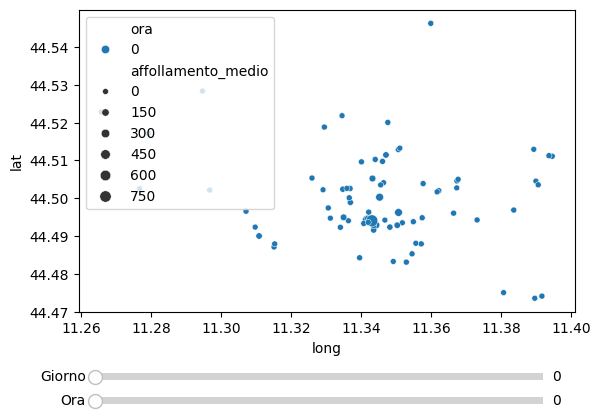

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.widgets import Slider
import matplotlib
# matplotlib.use("TkAgg")

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update_plot(giorno, ora):
    ax.clear()

    mask = (df["data"] == giorno) & (df["ora"] == ora)
    filt_df = df[mask]

    print(filt_df.head())

    sns.scatterplot(
        data=filt_df,
        x="long",
        y="lat",
        size="affollamento_medio",
        hue="ora",
        ax=ax
    )

    fig.canvas.draw_idle()


# iniziali
giorno_init = df["data"].min()
ora_init = df["ora"].min()

update_plot(giorno_init, ora_init)

# slider giorno
ax_giorno = plt.axes([0.15, 0.1, 0.7, 0.03])
slider_giorno = Slider(
    ax_giorno,
    "Giorno",
    df["data"].min(),
    df["data"].max(),
    valinit=giorno_init,
    valstep=1
)

# slider ora
ax_ora = plt.axes([0.15, 0.05, 0.7, 0.03])
slider_ora = Slider(
    ax_ora,
    "Ora",
    df["ora"].min(),
    df["ora"].max(),
    valinit=ora_init,
    valstep=1
)


def on_change(val):
    update_plot(int(slider_giorno.val), int(slider_ora.val))


slider_giorno.on_changed(on_change)
slider_ora.on_changed(on_change)

plt.show()

In [25]:
%matplotlib inline
plt.figure()
pv=pd.pivot_table(data=df,index='ora',columns='giorno',values='affollamento_medio' ,aggfunc='count')

print(pv)
plt.show()

giorno     1     2     3     4     5     6     7
ora                                             
0       1596  1520  1536  1610  1596  1596  1596
1       1596  1520  1534  1605  1596  1596  1596
2       1596  1520  1520  1596  1596  1596  1520
3       1596  1520  1520  1596  1596  1596  1633
4       1596  1520  1520  1596  1596  1596  1596
5       1596  1520  1520  1596  1596  1596  1596
6       1596  1520  1520  1596  1596  1596  1596
7       1596  1520  1520  1596  1596  1596  1596
8       1596  1520  1520  1596  1596  1596  1596
9       1596  1520  1520  1596  1596  1596  1596
10      1596  1520  1520  1596  1596  1596  1596
11      1596  1520  1520  1596  1596  1596  1596
12      1596  1520  1520  1596  1596  1596  1596
13      1596  1520  1520  1596  1596  1596  1596
14      1596  1520  1520  1596  1596  1596  1596
15      1596  1520  1520  1596  1596  1596  1596
16      1596  1520  1520  1596  1596  1596  1596
17      1596  1520  1520  1596  1596  1596  1596
18      1596  1520  

<Figure size 640x480 with 0 Axes>

In [47]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X=df.drop(columns='affollamento_medio')
y=df['affollamento_medio']
X=scaler.fit_transform(X)

mean_y=y.mean()
std_y=y.std()

# y=[(t-mean_y)/std_y for t in y]


In [48]:
print(mean_y)
print(std_y)
print(y[0:6])

40.53040900738769
91.69385124619096
0    110
1     50
2     10
3     30
4      0
5     70
Name: affollamento_medio, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
model= LinearRegression()

model.fit(X=X_train,y=y_train)

preds=model.predict(X=X_test)
print(mean_absolute_error(y_true=y_test, y_pred=preds))

48.95950417383855


In [54]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
model= XGBRegressor(n_estimators=200, max_depth=10, eta=0.1, subsample=0.7, colsample_bytree=0.8)

model.fit(X=X_train,y=y_train)

preds=model.predict(X=X_test)
print(mean_absolute_error(y_true=y_test, y_pred=preds))

7.3798346519470215


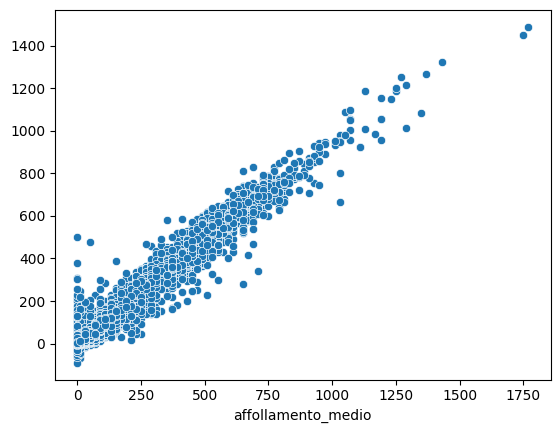

          real      pred
real  1.000000  0.986781
pred  0.986781  1.000000


In [55]:
y_frame=pd.DataFrame()
y_frame['real']=y_test
y_frame['pred']=preds


plt.figure()
sns.scatterplot(x=y_test,y=preds)

plt.show()

print(y_frame.corr())